In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

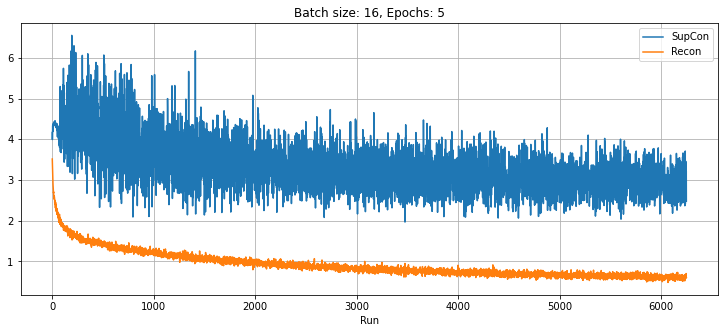

Epoch done. Runtime: 9 mins 57 secs.
All done. Total runtime: 0 hr 49  min 24 sec.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from seqAE_model import SeqAutoencoder
from training_functions import *

# # # # # # # # # # # #
BS = 16
E = 5
use_losses = ['Recon']
v = 'a06'
ds_v = '01'
use_cuda = True
# # # # # # # # # # # #

ds, loader = get_ds_and_loader(ds_v, BS)
model = SeqAutoencoder(dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)
torch.cuda.empty_cache()
device =  torch.device("cuda" if use_cuda else "cpu")

if use_cuda and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model, device_ids = [0, 1, 2, 3])
    model.to(device)
else:
    model = model.to(device)
    
optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001) 
model.train()
torch.set_grad_enabled(True)

today = datetime.today().strftime('%Y%m%d%H')
tag = f'{today}_{v}'

print(tag)
model = fit(model, device, optimizer, loader, use_losses, v, bs=BS, n_epochs=E, 
            normed_latent=True, do_plot=True, save_step=5)